<a href="https://colab.research.google.com/github/agusgonella/challenge_telecom_x_parte2/blob/main/TelecomX_Parte_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Extracción del archivo tratado y Eliminación de Columnas Irrelevantes

In [4]:
import pandas as pd

In [ ]:
datos = pd.read_csv('/content/datos_tratados.csv', index_col=0)

In [6]:
#Para poder ver todas las columnas
pd.set_option('display.max_columns', None)

In [7]:
datos.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,0,1,0,1,Yes,0,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,0,0,0,0,No,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,0,0,1,0,No,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,0,1,1,0,Yes,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,0,0,0,1,Yes,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667


In [8]:
#Vamos a eliminar la columna customerID

datos = datos.drop(columns = ['customerID'])

In [9]:
datos.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0,Female,0,1,1,9,1,No,DSL,0,1,0,1,Yes,0,One year,1,Mailed check,65.6,593.30,2.186667
1,0,Male,0,0,0,9,1,Yes,DSL,0,0,0,0,No,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,1,Male,0,0,0,4,1,No,Fiber optic,0,0,1,0,No,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,1,Male,1,1,0,13,1,No,Fiber optic,0,1,1,0,Yes,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,1,Female,1,1,0,3,1,No,Fiber optic,0,0,0,1,Yes,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667


##Encoding

In [10]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7267 non-null   int64  
 1   gender            7267 non-null   object 
 2   SeniorCitizen     7267 non-null   int64  
 3   Partner           7267 non-null   int64  
 4   Dependents        7267 non-null   int64  
 5   tenure            7267 non-null   int64  
 6   PhoneService      7267 non-null   int64  
 7   MultipleLines     7267 non-null   object 
 8   InternetService   7267 non-null   object 
 9   OnlineSecurity    7267 non-null   int64  
 10  OnlineBackup      7267 non-null   int64  
 11  DeviceProtection  7267 non-null   int64  
 12  TechSupport       7267 non-null   int64  
 13  StreamingTV       7267 non-null   object 
 14  StreamingMovies   7267 non-null   int64  
 15  Contract          7267 non-null   object 
 16  PaperlessBilling  7267 non-null   int64  
 17  

In [11]:
#Como podemos ver, tenemos varias variables explicativas que son de tipo 'object'. Dado a que los Los algoritmos de aprendizaje
#automático no comprenden datos en formato de texto, debemos transformar los datos a un formato numérico para que el algoritmo pueda interpretar la información.

#Las columnas que transformaremos serán: gender, MultipleLines, InternetService, StreamingTV, Contract y PaymentMethod.
#Cabe destacar que en el Challenge anterior, traté de forma incorrecta estas columnas, ya que no sabía que existian las herramientas de 'OneHotEncoder' y 'get_dummies()'.

#A la hora de entrenar un modelo de Machine Learning se aconseja usar OneHotEncoder, por lo que en esta ocasión lo escogemos.

In [12]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [13]:
one_hot = make_column_transformer((
    OneHotEncoder(drop = 'if_binary'),
    ['gender', 'MultipleLines', 'InternetService', 'StreamingTV', 'Contract','PaymentMethod']
),
    remainder = 'passthrough',
    sparse_threshold=0,
    force_int_remainder_cols=False)

In [14]:
columnas = datos.columns

In [15]:
X = one_hot.fit_transform(datos)

In [16]:
datos = pd.DataFrame(X, columns = one_hot.get_feature_names_out(columnas))

In [17]:
datos.head()

,onehotencoder__gender_Male,onehotencoder__MultipleLines_No,onehotencoder__MultipleLines_No phone service,onehotencoder__MultipleLines_Yes,onehotencoder__InternetService_DSL,onehotencoder__InternetService_Fiber optic,onehotencoder__InternetService_No,onehotencoder__StreamingTV_No,onehotencoder__StreamingTV_No internet service,onehotencoder__StreamingTV_Yes,onehotencoder__Contract_Month-to-month,onehotencoder__Contract_One year,onehotencoder__Contract_Two year,onehotencoder__PaymentMethod_Bank transfer (automatic),onehotencoder__PaymentMethod_Credit card (automatic),onehotencoder__PaymentMethod_Electronic check,onehotencoder__PaymentMethod_Mailed check,remainder__Churn,remainder__SeniorCitizen,remainder__Partner,remainder__Dependents,remainder__tenure,remainder__PhoneService,remainder__OnlineSecurity,remainder__OnlineBackup,remainder__DeviceProtection,remainder__TechSupport,remainder__StreamingMovies,remainder__PaperlessBilling,remainder__Charges.Monthly,remainder__Charges.Total,remainder__Cuentas_Diarias
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,9.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,65.6,593.30,2.186667
1,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,9.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,59.9,542.40,1.996667
2,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,4.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,73.9,280.85,2.463333
3,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,13.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,98.0,1237.85,3.266667
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,3.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,83.9,267.40,2.796667


##Verificación de la Proporción de Cancelación (Churn)

In [18]:
#Recordar que: 0 = No y 1 = Yes, por lo que: hay 5398 personas que no cancelaron y 1869 que si cancelaron (se dieron de baja = son churn)

churn = datos['remainder__Churn'].value_counts()
churn

,count
remainder__Churn,
0.0,5398
1.0,1869


In [19]:
import matplotlib.pyplot as plt

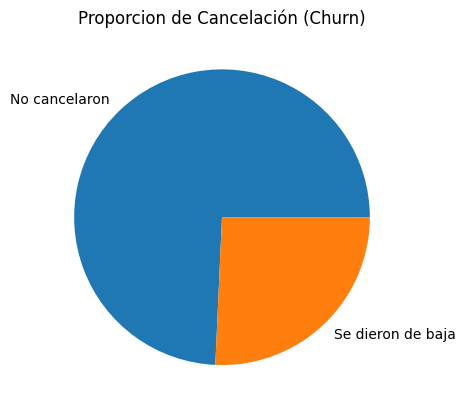

In [20]:
mylabels = ['No cancelaron', 'Se dieron de baja']
plt.pie(data=datos, x=churn, labels = mylabels)
plt.title('Proporcion de Cancelación (Churn)')
plt.show()

#Hay más personas que no cancelaron

##Análisis de Correlación

In [22]:
#Matriz de correlación

datos.corr()

,onehotencoder__gender_Male,onehotencoder__MultipleLines_No,onehotencoder__MultipleLines_No phone service,onehotencoder__MultipleLines_Yes,onehotencoder__InternetService_DSL,onehotencoder__InternetService_Fiber optic,onehotencoder__InternetService_No,onehotencoder__StreamingTV_No,onehotencoder__StreamingTV_No internet service,onehotencoder__StreamingTV_Yes,onehotencoder__Contract_Month-to-month,onehotencoder__Contract_One year,onehotencoder__Contract_Two year,onehotencoder__PaymentMethod_Bank transfer (automatic),onehotencoder__PaymentMethod_Credit card (automatic),onehotencoder__PaymentMethod_Electronic check,onehotencoder__PaymentMethod_Mailed check,remainder__Churn,remainder__SeniorCitizen,remainder__Partner,remainder__Dependents,remainder__tenure,remainder__PhoneService,remainder__OnlineSecurity,remainder__OnlineBackup,remainder__DeviceProtection,remainder__TechSupport,remainder__StreamingMovies,remainder__PaperlessBilling,remainder__Charges.Monthly,remainder__Charges.Total,remainder__Cuentas_Diarias
onehotencoder__gender_Male,1.000000,0.004705,0.005073,-0.007805,0.004520,-0.009572,0.006318,0.003070,0.006318,-0.008451,-0.001312,0.007328,-0.005449,-0.018361,0.000700,0.002060,0.015057,-0.009555,-0.004288,-0.005007,0.012038,0.005765,-0.005073,-0.016974,-0.013494,-0.002740,-0.009112,-0.012475,-0.011273,-0.013889,0.000367,-0.013889
onehotencoder__MultipleLines_No,0.004705,1.000000,-0.316006,-0.822101,-0.070570,-0.190336,0.310160,0.006297,0.310160,-0.269462,0.087396,0.000982,-0.102738,-0.069441,-0.063683,-0.082131,0.222968,-0.031430,-0.136923,-0.128382,0.025280,-0.321778,0.316006,-0.152619,-0.233718,-0.243146,-0.154790,-0.276632,-0.153251,-0.338677,-0.395364,-0.338677
onehotencoder__MultipleLines_No phone service,0.005073,-0.316006,1.000000,-0.280379,0.454989,-0.291040,-0.173109,0.120688,-0.173109,0.025362,0.002201,0.001391,-0.003888,-0.007406,0.010668,-0.004788,0.002225,-0.012571,-0.010060,-0.018828,0.003863,-0.010205,-1.000000,0.093341,0.052165,0.073033,0.097573,0.034345,-0.013624,-0.246709,-0.113985,-0.246709
onehotencoder__MultipleLines_Yes,-0.007805,-0.822101,-0.280379,1.000000,-0.201638,0.367220,-0.209917,-0.078795,-0.209917,0.257405,-0.089742,-0.001828,0.106277,0.074701,0.058029,0.085968,-0.226920,0.039343,0.144567,0.141187,-0.027894,0.331678,0.280379,0.098396,0.205156,0.202172,0.098053,0.259268,0.163225,0.490699,0.468405,0.490699
onehotencoder__InternetService_DSL,0.004520,-0.070570,0.454989,-0.201638,1.000000,-0.639664,-0.380469,0.303573,-0.380469,0.017167,-0.064248,0.047030,0.030054,0.025241,0.053696,-0.105013,0.040682,-0.120020,-0.108192,-0.003166,0.052072,0.010421,-0.454989,0.319329,0.158484,0.144904,0.311817,0.023744,-0.060781,-0.160723,-0.054389,-0.160723
onehotencoder__InternetService_Fiber optic,-0.009572,-0.190336,-0.291040,0.367220,-0.639664,1.000000,-0.467474,0.066560,-0.467474,0.329575,0.243291,-0.073950,-0.212975,-0.025669,-0.050565,0.339716,-0.307197,0.300949,0.255271,0.002678,-0.168028,0.020815,0.291040,-0.027895,0.166285,0.178009,-0.018282,0.325911,0.327790,0.788453,0.363633,0.788453
onehotencoder__InternetService_No,0.006318,0.310160,-0.173109,-0.209917,-0.380469,-0.467474,1.000000,-0.429212,1.000000,-0.416266,-0.218822,0.034884,0.221674,0.001855,-0.000918,-0.287952,0.322812,-0.224051,-0.182697,0.000419,0.142274,-0.037029,0.173109,-0.333690,-0.382331,-0.380818,-0.336616,-0.419421,-0.324473,-0.763772,-0.374948,-0.763772
onehotencoder__StreamingTV_No,0.003070,0.006297,0.120688,-0.078795,0.303573,0.066560,-0.429212,1.000000,-0.429212,-0.642566,0.295518,-0.092172,-0.256460,-0.046402,-0.041591,0.097339,-0.023090,0.126795,0.050994,-0.124279,-0.104966,-0.247669,-0.120688,0.105051,0.040881,-0.070882,0.007143,-0.174356,0.050355,0.018943,-0.196783,0.018943
onehotencoder__StreamingTV_No internet service,0.006318,0.310160,-0.173109,-0.209917,-0.380469,-0.467474,1.000000,-0.429212,1.000000,-0.416266,-0.218822,0.034884,0.221674,0.001855,-0.000918,-0.287952,0.322812,-0.224051,-0.182697,0.000419,0.142274,-0.037029,0.173

In [23]:
import numpy as np

#Calculamos la matriz y reemplazamos los 1 perfectos por nulos
matriz_corr = datos.corr().replace(1.0, np.nan)

#Obtenemos el valor máximo y el nombre de la variable asociada
valores_maximos = matriz_corr.max()
variables_correlacionadas = matriz_corr.idxmax()

#Juntamos todo en un DataFrame nuevo para que quede prolijo y fácil de leer
resumen_correlaciones = pd.DataFrame({
    'Correlacion_Maxima': valores_maximos,
    'Variable_Relacionada': variables_correlacionadas
})

print(resumen_correlaciones)

                                                    Correlacion_Maxima  \
onehotencoder__gender_Male                                    0.015057   
onehotencoder__MultipleLines_No                               0.316006   
onehotencoder__MultipleLines_No phone service                 0.454989   
onehotencoder__MultipleLines_Yes                              0.490699   
onehotencoder__InternetService_DSL                            0.454989   
onehotencoder__InternetService_Fiber optic                    0.788453   
onehotencoder__InternetService_No                             0.322812   
onehotencoder__StreamingTV_No                                 0.303573   
onehotencoder__StreamingTV_No internet service                0.322812   
onehotencoder__StreamingTV_Yes                                0.628874   
onehotencoder__Contract_Month-to-month                        0.395584   
onehotencoder__Contract_One year                              0.205970   
onehotencoder__Contract_Two year      

In [24]:
#Las variables que muestran una mayor correlación son:
# - InternetService_Fiber optic con Charges.Monthly
# - StreamingTV_Yes con Charges.Monthly
# - tenure con Charges.Total
# - StreamingMovies con Charges.Monthly
# - Cuentas_Diarias con InternetService_Fiber optic

##Análisis Dirigido

In [25]:
#Investigamos cómo variables específicas se relacionan con la cancelación, tales como:
# - Tiempo de contrato × Cancelación
# - Gasto total × Cancelación

#Utilizamos gráficos como boxplots o scatter plots para visualizar patrones y posibles tendencias.

In [26]:
import seaborn as sns

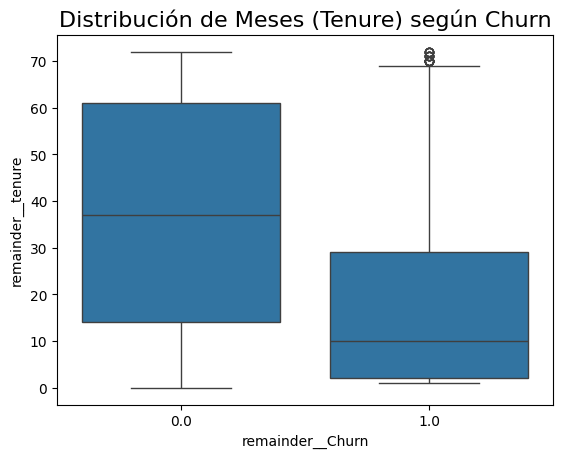

In [27]:
#Tiempo de contrato x Cancelación

ax = sns.boxplot(
    data=datos,
    x='remainder__Churn',
    y='remainder__tenure',
)
ax.set_title('Distribución de Meses (Tenure) según Churn', fontsize=16)
plt.show()

In [28]:
#Este gráfico demuestra visualmente y sin lugar a dudas que el riesgo de cancelación (Churn) es altísimo al principio del contrato.
#Si logras retener a un cliente más allá del mes 30 (donde termina la caja principal de cancelaciones), la probabilidad de que se quede contigo a largo plazo aumenta drásticamente.

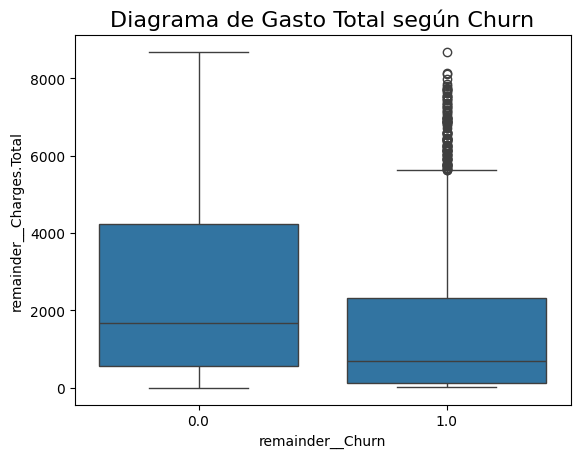

In [29]:
#Gasto total x Contratación

ax = sns.boxplot(
    data=datos,
    x='remainder__Churn',
    y='remainder__Charges.Total',
)

ax.set_title('Diagrama de Gasto Total según Churn', fontsize=16)
plt.show()

In [30]:
#Este gráfico muestra que como los clientes se van rápido, no tienen tiempo de acumular un gasto alto.
#Esto significa que la empresa está gastando dinero en adquirir clientes nuevos que no llegan a ser rentables porque se dan de baja antes de generar un retorno de inversión significativo.

#También podemos ver que tenemos muchos outliers: o sea que, hay clientes históricos y de muy alto valor (que llegaron a gastar entre 6000 y 8000 en total)
#que, de un momento a otro, decidieron cancelar. Sería de vital importancia averiguar por qué se fueron esos clientes específicos. Perder a uno de esos clientes duele mucho más financieramente que perder a diez clientes nuevos.

#Estos gráficos demuestran que tanto el tiempo de contrato como el gasto total son variables con un alto poder predictivo.

#Modelado Predictivo

##Separación de Datos

In [31]:
#Dividiremos el conjunto de datos en entrenamiento y prueba para evaluar el rendimiento del modelo.

x = datos.drop('remainder__Churn', axis = 1)
y = datos['remainder__Churn']

In [32]:
x

,onehotencoder__gender_Male,onehotencoder__MultipleLines_No,onehotencoder__MultipleLines_No phone service,onehotencoder__MultipleLines_Yes,onehotencoder__InternetService_DSL,onehotencoder__InternetService_Fiber optic,onehotencoder__InternetService_No,onehotencoder__StreamingTV_No,onehotencoder__StreamingTV_No internet service,onehotencoder__StreamingTV_Yes,onehotencoder__Contract_Month-to-month,onehotencoder__Contract_One year,onehotencoder__Contract_Two year,onehotencoder__PaymentMethod_Bank transfer (automatic),onehotencoder__PaymentMethod_Credit card (automatic),onehotencoder__PaymentMethod_Electronic check,onehotencoder__PaymentMethod_Mailed check,remainder__SeniorCitizen,remainder__Partner,remainder__Dependents,remainder__tenure,remainder__PhoneService,remainder__OnlineSecurity,remainder__OnlineBackup,remainder__DeviceProtection,remainder__TechSupport,remainder__StreamingMovies,remainder__PaperlessBilling,remainder__Charges.Monthly,remainder__Charges.Total,remainder__Cuentas_Diarias
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,9.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,65.60,593.30,2.186667
1,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,9.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,59.90,542.40,1.996667
2,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,73.90,280.85,2.463333
3,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,13.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,98.00,1237.85,3.266667
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,3.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,13.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,55.15,742.90,1.838333
7263,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,22.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,85.10,1873.70,2.836667
7264,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,50.30,92.75,1.676667
7265,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,67.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,67.85,4627.65,2.261667


In [33]:
y

,remainder__Churn
0,0.0
1,0.0
2,1.0
3,1.0
4,1.0
...,...
7262,0.0
7263,1.0
7264,0.0
7265,0.0


In [34]:
from sklearn.model_selection import train_test_split

In [35]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3)

##Creación de Modelos

###KNN: El algoritmo KNN se basa en el cálculo de la distancia entre los registros de la base de datos y busca elementos que estén cerca unos de otros (vecinos) para tomar la decisión de clasificación.
#####Debido a que utiliza cálculos de distancia, este algoritmo está influenciado por la escala de las variables, necesitamos normalizar los datos (ya que no lo hicimos anteriormente). La normalización de los datos nos permite asegurar que el modelo evalúe el impacto real de la variable y no se deje engañar (sesgar) por la magnitud de sus números.

####Ejemplo:
#####La variable tenure va desde 0 hasta 72. Por otro lado, la variable Total_Charges va desde 0 hasta 8k dólares. Si no normalizáramos, al usar Regresión Lógica o KNN, el algoritmo pensaría: "¡Wow, 8000 es muchísimo más grande que 72, así que TotalCharges debe ser mil veces más importante!". La normalización toma todas las variables numéricas y las comprime a un rango similar (por ejemplo, entre 0 y 1, o centradas en 0).

In [36]:
from sklearn.preprocessing import MinMaxScaler

In [37]:
normalizacion = MinMaxScaler()
x_train_normalizado = normalizacion.fit_transform(x_train)

In [38]:
pd.DataFrame(x_train_normalizado)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30
0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.166667,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.880100,0.144379,0.880100
1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.180556,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.108458,0.041124,0.108458
2,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.291667,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.417910,0.144891,0.417910
3,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.722222,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.616418,0.494842,0.616418
4,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.722222,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.622886,0.469734,0.622886
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5081,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.083333,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.758706,0.066259,0.758706
5082,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.013889,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.664179,0.009787,0.664179
5083,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.319444,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.652239,0.218802,0.652239
5084,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.152778,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.543781,0.094239,0.543781


In [39]:
from sklearn.neighbors import KNeighborsClassifier

In [40]:
knn = KNeighborsClassifier()

In [41]:
knn.fit(x_train_normalizado, y_train)

KNeighborsClassifier()

In [42]:
x_test_normalizado = normalizacion.transform(x_test)

In [43]:
predicciones_knn = knn.predict(x_test_normalizado)

In [44]:
predicciones_knn_train = knn.predict(x_train_normalizado)

In [45]:
knn.score(x_test_normalizado, y_test)

0.756075194864741

###Árbol de Decisión: El modelo de árbol de decisión es muy utilizado debido a su alta explicabilidad y procesamiento rápido, manteniendo un rendimiento bastante interesante.
####Se basa en decisiones simples tomadas por el algoritmo, separando los datos mediante comparaciones de menor y mayor en los valores de las columnas de la base de datos.

In [46]:
from sklearn.tree import DecisionTreeClassifier

In [47]:
modelo_arbol = DecisionTreeClassifier(random_state = 5)
modelo_arbol.fit(x_train, y_train)

DecisionTreeClassifier(random_state=5)

In [48]:
modelo_arbol.predict(x_test)

array([1., 0., 0., ..., 0., 0., 0.])

In [49]:
modelo_arbol.score(x_test, y_test)

0.7354424575882622

In [50]:
valores_columnas = datos.columns
valores_columnas

Index(['onehotencoder__gender_Male', 'onehotencoder__MultipleLines_No',
       'onehotencoder__MultipleLines_No phone service',
       'onehotencoder__MultipleLines_Yes',
       'onehotencoder__InternetService_DSL',
       'onehotencoder__InternetService_Fiber optic',
       'onehotencoder__InternetService_No', 'onehotencoder__StreamingTV_No',
       'onehotencoder__StreamingTV_No internet service',
       'onehotencoder__StreamingTV_Yes',
       'onehotencoder__Contract_Month-to-month',
       'onehotencoder__Contract_One year', 'onehotencoder__Contract_Two year',
       'onehotencoder__PaymentMethod_Bank transfer (automatic)',
       'onehotencoder__PaymentMethod_Credit card (automatic)',
       'onehotencoder__PaymentMethod_Electronic check',
       'onehotencoder__PaymentMethod_Mailed check', 'remainder__Churn',
       'remainder__SeniorCitizen', 'remainder__Partner',
       'remainder__Dependents', 'remainder__tenure', 'remainder__PhoneService',
       'remainder__OnlineSecurity',

In [51]:
from sklearn.tree import plot_tree

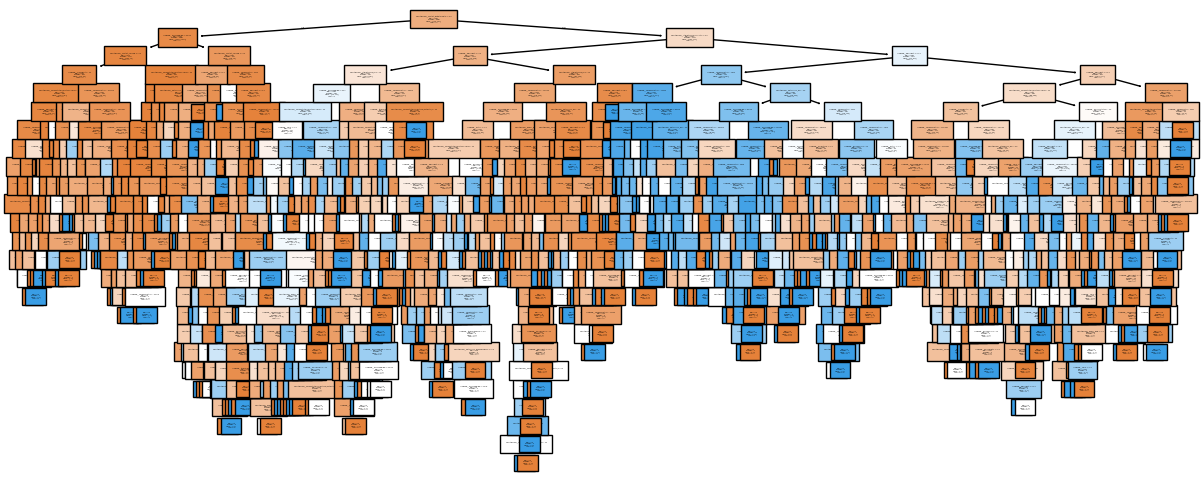

In [52]:
plt.figure(figsize = (15, 6))
plot_tree(modelo_arbol, filled = True, class_names = ['no', 'si'], fontsize = 1, feature_names = valores_columnas);

In [53]:
modelo_arbol = DecisionTreeClassifier(max_depth = 5, random_state =5) #Maximo 5 niveles
modelo_arbol.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=5)

In [54]:
modelo_arbol.score(x_train, y_train)

0.8049547778214707

In [55]:
predicciones_arbol = modelo_arbol.predict(x_test)

In [56]:
predicciones_arbol_train = modelo_arbol.predict(x_train)

In [57]:
modelo_arbol.score(x_test, y_test)

0.7767079321412196

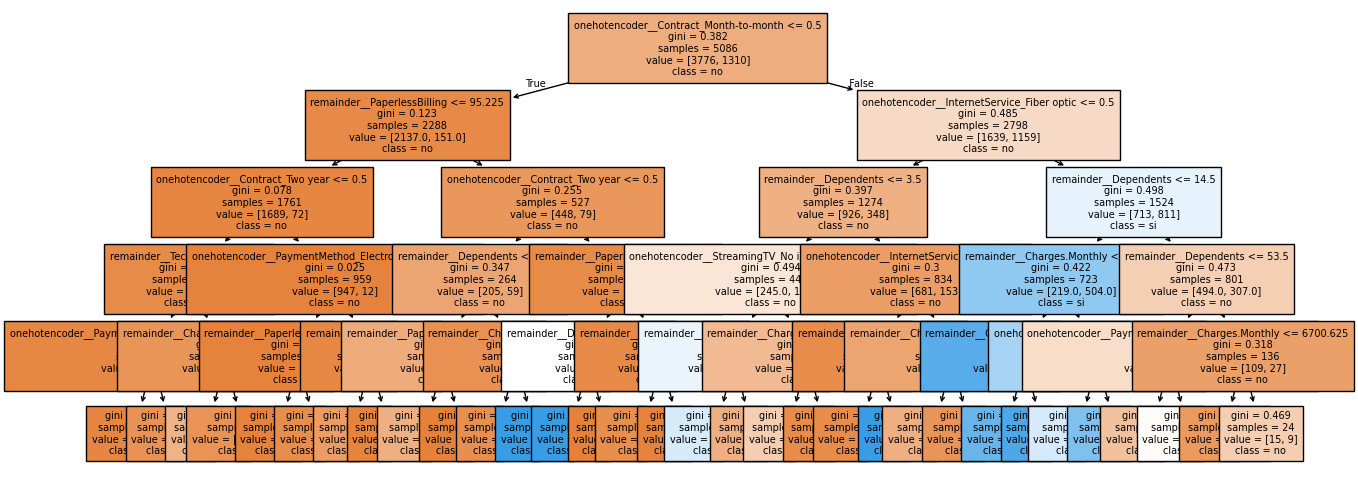

In [58]:
plt.figure(figsize = (15, 6))
plot_tree(modelo_arbol, filled = True, class_names = ['no', 'si'], fontsize = 7, feature_names = valores_columnas);

#Azul = SI, Rojo = NO

##Evaluación de los Modelos

In [59]:
#Calcularemos las siguientes métricas: Exactitud (Acurácia), Precisión, Recall, F1-score y Matriz de confusión

In [60]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

In [61]:
def evaluar_y_mostrar(y_real, y_pred, nombre_modelo):
    print(f"=== {nombre_modelo} ===")
    print(f"Exactitud (Accuracy): {accuracy_score(y_real, y_pred):.4f}")
    print(f"Precisión:            {precision_score(y_real, y_pred):.4f}")
    print(f"Recall:               {recall_score(y_real, y_pred):.4f}")
    print(f"F1-score:             {f1_score(y_real, y_pred):.4f}\n")

    #Dibujamos la matriz de confusión
    cm = confusion_matrix(y_real, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Se queda (0)', 'Cancela (1)'])
    disp.plot(cmap='Blues')
    plt.title(f'Matriz de Confusión: {nombre_modelo}')
    plt.grid(False)
    plt.show()

=== KNN ===
Exactitud (Accuracy): 0.7561
Precisión:            0.5259
Recall:               0.4902
F1-score:             0.5074



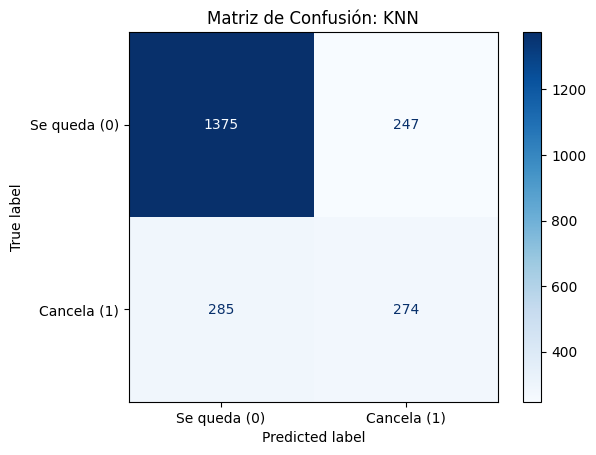

In [62]:
evaluar_y_mostrar(y_test, predicciones_knn, "KNN")

=== Árbol de Decisión ===
Exactitud (Accuracy): 0.7767
Precisión:            0.5878
Recall:               0.4311
F1-score:             0.4974



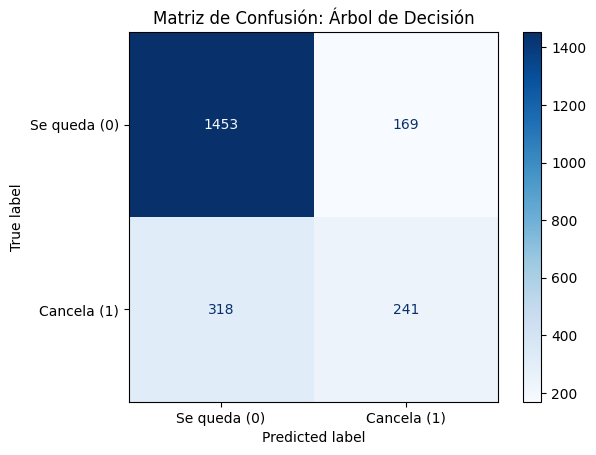

In [63]:
evaluar_y_mostrar(y_test, predicciones_arbol, "Árbol de Decisión")

###Comparación de los Modelos

###¿Cuál modelo tuvo el mejor desempeño?
#####El Árbol de Decisión, definitivamente. Podemos ver que:

##### - Recall (La métrica clave para Churn): El Árbol logra casi un 59%, frente a un 51.5% del KNN. Esto significa que el Árbol de Decisión es significativamente mejor detectando a los clientes que realmente van a cancelar, dejando escapar a menos personas.

##### - Exactitud (Accuracy): Sube de 75.6% a 78.1%.

##### - F1-Score: Su 0.586 demuestra un mejor equilibrio general entre precisión y sensibilidad comparado con el 0.527 del KNN.

###Rendimiento en entrenamiento y prueba de KNN

In [64]:
print("--- RENDIMIENTO EN ENTRENAMIENTO (Train) ---")
print(f"Exactitud: {accuracy_score(y_train, predicciones_knn_train):.4f}")
print(f"F1-Score:  {f1_score(y_train, predicciones_knn_train):.4f}\n")

print("--- RENDIMIENTO EN PRUEBA (Test) ---")
print(f"Exactitud: {accuracy_score(y_test, predicciones_knn):.4f}")
print(f"F1-Score:  {f1_score(y_test, predicciones_knn):.4f}")

--- RENDIMIENTO EN ENTRENAMIENTO (Train) ---
Exactitud: 0.8366
F1-Score:  0.6626

--- RENDIMIENTO EN PRUEBA (Test) ---
Exactitud: 0.7561
F1-Score:  0.5074


##Rendimiento en entrenamiento y prueba del Árbol de Decisión

In [65]:
print("--- RENDIMIENTO EN ENTRENAMIENTO (Train) ---")
print(f"Exactitud: {accuracy_score(y_train, predicciones_arbol_train):.4f}")
print(f"F1-Score:  {f1_score(y_train, predicciones_arbol_train):.4f}\n")

print("--- RENDIMIENTO EN PRUEBA (Test) ---")
print(f"Exactitud: {accuracy_score(y_test, predicciones_arbol):.4f}")
print(f"F1-Score:  {f1_score(y_test, predicciones_arbol):.4f}")

--- RENDIMIENTO EN ENTRENAMIENTO (Train) ---
Exactitud: 0.8050
F1-Score:  0.5645

--- RENDIMIENTO EN PRUEBA (Test) ---
Exactitud: 0.7767
F1-Score:  0.4974


###¿Algún modelo presentó overfitting o underfitting?

####Podemos concluir que el modelo KNN presenta Overfitting (Sobreajuste).

#####- F1 score: En el entrenamiento saca un 0.6621, pero cuando se enfrenta a los datos de prueba, se desploma drásticamente a 0.5272. El algoritmo memorizó demasiado bien a los clientes específicos del set de entrenamiento. Al llegar clientes nuevos en el set de prueba, no supo cómo generalizar y falló.

#####Ajustes posibles: Podemos reducir la complejidad del modelo o aumentar los datos de entrenamiento.

####Con respecto al Árbol de Decisión, podemos concluir tiene un comportamiento muy sano y generaliza muy bien.
#####Sin embargo, podriamos mejorar algunas cosas: cambiar el *max_depth* un poco para que el árbol haga una o dos preguntas más antes de decidir. Ésto aumentaría un poco la complejidad, lo cual es totalmente cierto ya que le puse un *max_depth = 5* que es bastante estricto ya que el árbol original (sin el límite de profundidad) era muchísimo más grande, es decir, tenia una profundidad más grande.


##Análisis de la Importancia de las **Variables**

In [72]:
#KNN
from sklearn.inspection import permutation_importance

In [81]:
#Elegimos al primer cliente de tus datos de prueba
cliente_ejemplo = x_test.iloc[[0]]

#Le pedimos al KNN que busque a sus 5 vecinos más cercanos
distancias, indices_vecinos = knn.kneighbors(cliente_ejemplo, n_neighbors=5)

#Mostramos los datos originales de esos 5 vecinos para compararlos
vecinos_cercanos = x_train.iloc[indices_vecinos[0]]

print("--- DATOS DEL CLIENTE A PREDECIR ---")
print(cliente_ejemplo.T)

print("\n--- SUS 5 VECINOS MÁS CERCANOS ---")
print(vecinos_cercanos.T)

--- DATOS DEL CLIENTE A PREDECIR ---
                                                         4546
onehotencoder__gender_Male                           0.000000
onehotencoder__MultipleLines_No                      1.000000
onehotencoder__MultipleLines_No phone service        0.000000
onehotencoder__MultipleLines_Yes                     0.000000
onehotencoder__InternetService_DSL                   0.000000
onehotencoder__InternetService_Fiber optic           1.000000
onehotencoder__InternetService_No                    0.000000
onehotencoder__StreamingTV_No                        1.000000
onehotencoder__StreamingTV_No internet service       0.000000
onehotencoder__StreamingTV_Yes                       0.000000
onehotencoder__Contract_Month-to-month               1.000000
onehotencoder__Contract_One year                     0.000000
onehotencoder__Contract_Two year                     0.000000
onehotencoder__PaymentMethod_Bank transfer (aut...   0.000000
onehotencoder__PaymentMethod_Cred

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


In [80]:
#El modelo KNN interno fue entrenado con datos normalizados (escalados). Como nosotros le pasamos los datos del cliente_ejemplo directamente crudos, el algoritmo se confundió por la diferencia gigantesca
#en las magnitudes y agrupó a personas completamente opuestas. Esto demuestra empíricamente por qué KNN es hiper-sensible a la escala de los datos.

In [79]:
#Para que el modelo trabaje bien, primero debemos pasar a nuestro cliente por el "filtro" de la normalización.

In [84]:
#Normalizamos
cliente_normalizado = normalizacion.transform(cliente_ejemplo)

#Formateamos al cliente de vuelta como un DataFrame bonito para imprimirlo
cliente_formateado = pd.DataFrame(cliente_normalizado, columns=nombres_columnas).T
cliente_formateado.columns = ['Cliente 4546'] # Le damos un nombre a la columna

#Buscamos los vecinos
distancias, indices_vecinos = knn.kneighbors(cliente_normalizado, n_neighbors=5)

#Formateamos a los vecinos
vecinos_cercanos = x_train.iloc[indices_vecinos[0]].T

#Imprimimos todo
print("--- DATOS DEL CLIENTE A PREDECIR ---")
print(cliente_formateado) #Recordar que esto muestra el cliente NORMALIZADO

print("\n--- SUS 5 VECINOS MÁS CERCANOS ---")
print(vecinos_cercanos)

--- DATOS DEL CLIENTE A PREDECIR ---
                                                    Cliente 4546
onehotencoder__gender_Male                              0.000000
onehotencoder__MultipleLines_No                         1.000000
onehotencoder__MultipleLines_No phone service           0.000000
onehotencoder__MultipleLines_Yes                        0.000000
onehotencoder__InternetService_DSL                      0.000000
onehotencoder__InternetService_Fiber optic              1.000000
onehotencoder__InternetService_No                       0.000000
onehotencoder__StreamingTV_No                           1.000000
onehotencoder__StreamingTV_No internet service          0.000000
onehotencoder__StreamingTV_Yes                          0.000000
onehotencoder__Contract_Month-to-month                  1.000000
onehotencoder__Contract_One year                        0.000000
onehotencoder__Contract_Two year                        0.000000
onehotencoder__PaymentMethod_Bank transfer (aut...   

###Conclusiones - Modelo KNN:


* El modelo agrupó a clientes que son clones en sus decisiones comerciales. Casi todos los vecinos comparten exactamente el mismo combo: Tienen Fibra Óptica, pagan Mes a Mes (Month-to-month) y usan Cheque Electrónico. Esto nos concluye que estas variables son determinantes (impactan muchísimo) para acercar o alejar a los clientes entre sí.
* El cliente original es muy nuevo (1 mes de antigüedad). Si observamos a los vecinos, el modelo trajo a personas con antigüedades relativamente bajas o medias (2, 13, 18, 32 meses). Ya no trajo a clientes de 72 meses como antes. Esto demuestra que la normalización funcionó perfectamente y el modelo ahora agrupa correctamente a los clientes por su "etapa de madurez" en la empresa.
* La variable *Charges.Monthly* demostró ser muy importante.
Tu cliente inicial gastaba $85. El modelo fue a buscar a clientes que gastan entre \$74 y \$86. Esto nos indica que el nivel de facturación mensual es una dimensión clave para calcular qué tan parecidos son dos clientes, mucho más que otras métricas.
* Si en el pasado la mayoría de ellos canceló su servicio, el algoritmo predecirá automáticamente que el Cliente 4546 también va a cancelar. Es un modelo basado enteramente en la similitud de perfiles


####La combinación de estas variables importantes (Fibra Óptica + Contrato Mensual + Facturación Media/Alta) describe un perfil de cliente exigente y con alta facilidad para cancelar (no hay penalidad por irse). Dado que estas variables tempranas definen el riesgo, retenerlos desde el primer momento es vital


In [ ]:
#Árbol de Decisión

In [90]:
importances = modelo_arbol.feature_importances_

In [96]:
feature_importances = pd.DataFrame({'Features':x.columns,'Importances':(importances*100).round(2)}).sort_values('Importances',ascending=False)

print("--- TOP 15 VARIABLES MÁS IMPORTANTES (Árbol de Decisión) ---")
print(feature_importances.head(15))

--- TOP 15 VARIABLES MÁS IMPORTANTES (Árbol de Decisión) ---
                                          Features  Importances
10          onehotencoder__Contract_Month-to-month        49.04
20                               remainder__tenure        21.24
5       onehotencoder__InternetService_Fiber optic        14.96
29                        remainder__Charges.Total         4.23
28                      remainder__Charges.Monthly         2.79
8   onehotencoder__StreamingTV_No internet service         1.63
12                onehotencoder__Contract_Two year         1.46
15   onehotencoder__PaymentMethod_Electronic check         1.45
3                 onehotencoder__MultipleLines_Yes         1.44
4               onehotencoder__InternetService_DSL         1.01
26                      remainder__StreamingMovies         0.41
30                      remainder__Cuentas_Diarias         0.26
21                         remainder__PhoneService         0.07
6                onehotencoder__InternetSer

###Conclusiones - Modelo Árbol de Decisión:


* **Contract_Month-to-month**: Casi la mitad de las decisiones que toma el modelo para predecir la cancelación se basan en ésta varuable. Si un cliente no tiene un compromiso a largo plazo (contrato de 1 o 2 años), su riesgo de irse es inmenso. Al no haber barreras de salida (como penalidades por cancelar), abandonan el servicio ante el menor error comercial o porque consiguen una opción un poco mejor en otra empresa.

* **Tenure**: los clientes toman la decisión de quedarse o irse muy temprano en su ciclo de vida. Si sumas esta variable con la del contrato mensual, tienes el perfil exacto del desertor: Alguien nuevo que paga mes a mes.

* **Internet - Fibra Óptica**: generalmente, la fibra óptica es el servicio más caro y premium. Si esto genera cancelaciones, la empresa debe investigar urgentemente si hay problemas de cortes de servicio, si la competencia ofrece lo mismo mucho más barato, o si las expectativas de los clientes premium no se están cumpliendo.

* El Gasto Total (Charges.Total con 4.23%) y el Gasto Mensual (2.79%) quedaron siendo un poco irrelevantes. Solo las primeras 3 variables de la tabla suman el 85.24% de la importancia predictiva. Al modelo casi no le importa cuánto gastan, si son mayores de edad o si tienen múltiples líneas. Si se quiere mejorar, la empresa debe enfocarse *exclusivamente* en atacar esos tres primeros puntos.



#Informe Final

El análisis del comportamiento de los clientes evaluó múltiples enfoques para predecir y mitigar el riesgo de cancelación. A continuación se detallan los hallazgos definitivos sobre el rendimiento de los algoritmos, los motivos principales de abandono y las acciones correctivas sugeridas.

1. **Evaluación y Rendimiento de los Modelos**: Se entrenaron y compararon dos modelos predictivos principales: un Árbol de Decisión y un K-Nearest Neighbors (KNN).

> | Métrica de Evaluación | Árbol de Decisión | K-Nearest Neighbors (KNN) |
> | :--- | :--- | :--- |
> | **Exactitud (Accuracy)** | 78.13% | 75.65% |
> | **Precisión** | 58.38% | 53.92% |
> | **Recall (Sensibilidad)** | 58.89% | 51.57% |
> | **F1-Score** | 0.5863 | 0.5272 |

* El Árbol de Decisión se consolida como el modelo con mejor desempeño. Su ventaja principal radica en la métrica de Recall, logrando detectar de manera preventiva a casi el 59% de los clientes que efectivamente van a abandonar el servicio. Adicionalmente, este modelo demostró una capacidad de generalización mucho más estable, superando el sobreajuste (overfitting) masivo que penalizó al algoritmo KNN al enfrentarse a datos nuevos.

2. **Factores Críticos de Cancelación**: La extracción de la importancia de las variables (Feature Importance) del modelo ganador revela que el riesgo de fuga está fuertemente concentrado. Las tres variables principales agrupan más del 85% del peso predictivo de las decisiones del cliente:
- La variable Contract_Month-to-month domina el modelo con un 49.04% de importancia. Los clientes que pagan mes a mes, al no tener barreras de salida ni penalidades, son el segmento más volátil.
- Antigüedad: La variable tenure acumula un 21.24% de la capacidad predictiva. El cruce de los datos confirma la existencia de una "zona de peligro" durante los primeros meses; si el cliente supera los dos años y medio en la empresa, la probabilidad de abandono se desploma.
- El uso del servicio InternetService_Fiber optic concentra el 14.96% del peso predictivo. Curiosamente, poseer este nivel de conectividad no retiene al cliente, sino que es un fuerte indicador de posible cancelación.

3. **Estrategias de Retención Recomendadas**
- Diseñar campañas agresivas dirigidas específicamente al segmento "mes a mes". Ofrecer un descuento temporal, mejoras en la velocidad o bonificaciones en el primer mes a cambio de que el cliente firme un contrato anual.

- Dado que la combinación de baja antigüedad y contrato mensual es el perfil de mayor riesgo, la atención inicial debe ser impecable. Mantener el dato medido de las 24 horas como un estándar innegociable de la operación garantiza que cualquier queja o problema de activación en clientes nuevos se resuelva antes de que decidan darse de baja impulsivamente.

- Investigar el motivo de la insatisfacción en el sector de fibra óptica. Se debe evaluar urgentemente si la red está sufriendo microcortes, si los routers no soportan las velocidades prometidas, o si los precios han quedado desactualizados frente a las ofertas de la/s competencia/s.